In [21]:
from collections import Counter, defaultdict
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

matplotlib.rcParams['font.sans-serif'] = ['Nanum Gothic', 'AppleGothic', 'Apple SD Gothic Neo']
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
print('준비 완료')

준비 완료


In [22]:
# ── 설정 ──────────────────────────────────────────────────────────────
CSV_PATH     = 'dummy_data.csv'
TOP_N_BRANDS = 15

# ── 로드 ──────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

def parse_brands(s):
    if pd.isna(s) or str(s).strip() == '':
        return []
    return [b.strip() for b in str(s).split(',') if b.strip()]

df['brand_list'] = df['언급된 브랜드'].apply(parse_brands)
df['has_brand']  = df['brand_list'].apply(len) > 0

brand_counter = Counter(b for bl in df['brand_list'] for b in bl)
top_brands    = [b for b, _ in brand_counter.most_common(TOP_N_BRANDS)]
types         = sorted(df['유형'].unique())
procedures    = sorted(df['procedure'].unique())

print(f'총 {len(df):,}행  |  상위 브랜드 {len(top_brands)}개')
print(f'유형: {types}')
print(f'시술: {procedures}')

총 1,000행  |  상위 브랜드 15개
유형: ['비교', '전문가', '추천', '후기']
시술: ['노안교정술', '라섹', '라식', '백내장 수술', '스마일라식']


## 분석 1 — 질문 유형별 브랜드 등장 히트맵
어떤 브랜드가 어떤 질문 유형에서 자주 나오는가?

/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Arial.
  fig.canvas.draw()
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/seaborn/utils.py:61: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) 

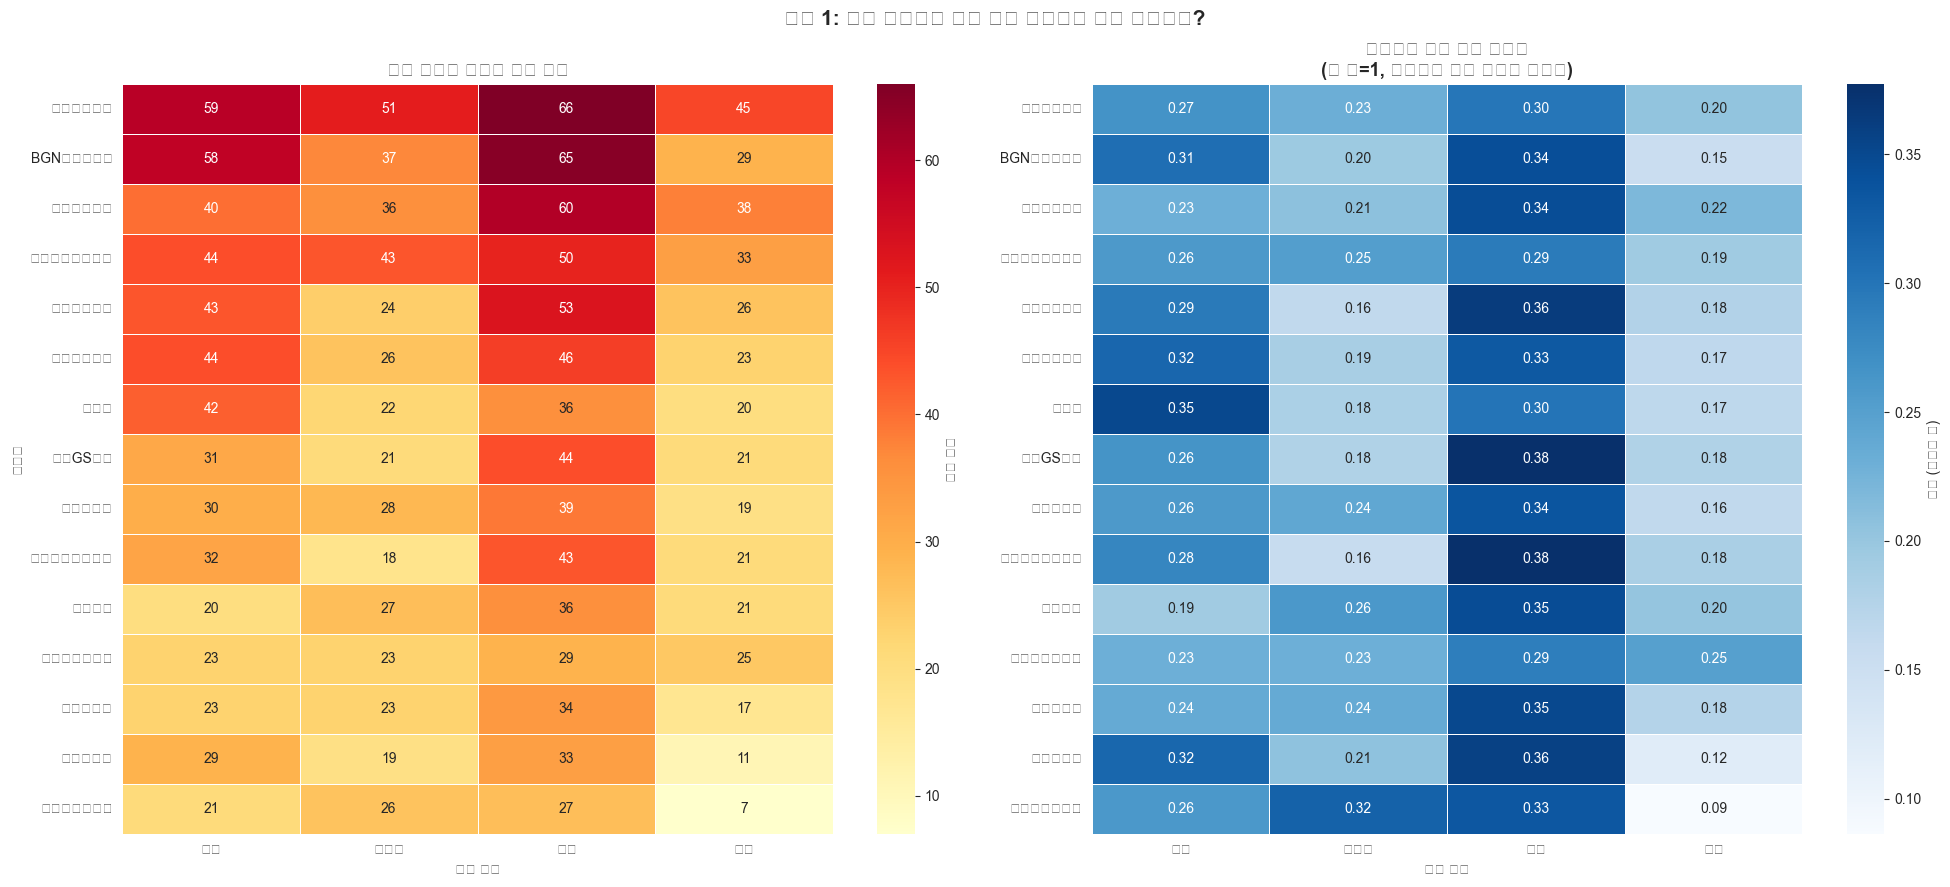


유형별 Top 3 브랜드:
  [비교] 아이리움안과(59회) | BGN밝은눈안과(58회) | 온누리스마일안과(44회)
  [전문가] 아이리움안과(51회) | 온누리스마일안과(43회) | BGN밝은눈안과(37회)
  [추천] 아이리움안과(66회) | BGN밝은눈안과(65회) | 누네안과병원(60회)
  [후기] 아이리움안과(45회) | 누네안과병원(38회) | 온누리스마일안과(33회)


In [23]:
type_brand = defaultdict(Counter)
for _, row in df.iterrows():
    for b in row['brand_list']:
        type_brand[row['유형']][b] += 1

mat_type = pd.DataFrame(
    {t: [type_brand[t].get(b, 0) for b in top_brands] for t in types},
    index=top_brands,
)
# 브랜드별 총 등장 대비 비율 (행 정규화 → 이 브랜드가 각 유형에 얼마나 치우쳐 있나)
mat_type_norm = mat_type.div(mat_type.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

sns.heatmap(mat_type, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.4, ax=axes[0], cbar_kws={'label': '등장 횟수'})
axes[0].set_title('질문 유형별 브랜드 등장 횟수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('질문 유형')
axes[0].set_ylabel('브랜드')

sns.heatmap(mat_type_norm, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, ax=axes[1], cbar_kws={'label': '비율 (브랜드 내)'})
axes[1].set_title('브랜드별 질문 유형 편중도\n(행 합=1, 높을수록 해당 유형에 치우침)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('질문 유형')

plt.suptitle('분석 1: 어떤 브랜드가 어떤 질문 유형에서 자주 나오는가?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis1_type_brand.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n유형별 Top 3 브랜드:')
for t in types:
    top3 = mat_type[t].nlargest(3)
    print(f'  [{t}] ' + ' | '.join(f'{b}({c:.0f}회)' for b, c in top3.items()))

## 분석 2 — 시술별 브랜드 등장 히트맵
어떤 브랜드가 어떤 시술 질문에서 강한가?

In [ ]:
proc_brand = defaultdict(Counter)
for _, row in df.iterrows():
    for b in row['brand_list']:
        proc_brand[row['procedure']][b] += 1

mat_proc = pd.DataFrame(
    {p: [proc_brand[p].get(b, 0) for b in top_brands] for p in procedures},
    index=top_brands,
)
mat_proc_norm = mat_proc.div(mat_proc.sum(axis=1).replace(0, 1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(mat_proc, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.4, ax=axes[0], cbar_kws={'label': '등장 횟수'})
axes[0].set_title('시술별 브랜드 등장 횟수', fontsize=13, fontweight='bold')
axes[0].set_xlabel('시술')
axes[0].set_ylabel('브랜드')
axes[0].tick_params(axis='x', rotation=20)

sns.heatmap(mat_proc_norm, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.4, ax=axes[1], cbar_kws={'label': '비율 (브랜드 내)'})
axes[1].set_title('브랜드별 시술 편중도\n(행 합=1, 높을수록 해당 시술에 특화)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('시술')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('분석 2: 어떤 브랜드가 어떤 시술에서 강한가?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis2_proc_brand.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n브랜드별 가장 강한 시술:')
for b in top_brands:
    best = mat_proc.loc[b].idxmax()
    cnt  = mat_proc.loc[b, best]
    print(f'  {b:<20} → {best} ({cnt:.0f}회)')

## 분석 3 — 브랜드 공동출현 클러스터링
같은 답변에 함께 자주 등장하는 브랜드끼리 묶임

In [ ]:
b2i  = {b: i for i, b in enumerate(top_brands)}
cooc = np.zeros((len(top_brands), len(top_brands)))

for _, row in df.iterrows():
    bl = [b for b in row['brand_list'] if b in b2i]
    for i, b1 in enumerate(bl):
        for b2 in bl[i+1:]:
            cooc[b2i[b1], b2i[b2]] += 1
            cooc[b2i[b2], b2i[b1]] += 1

cooc_df = pd.DataFrame(cooc, index=top_brands, columns=top_brands)

g = sns.clustermap(
    cooc_df, cmap='YlOrRd', figsize=(13, 11),
    annot=True, fmt='.0f', linewidths=0.3, method='ward',
    cbar_kws={'label': '공동 등장 횟수'},
)
g.ax_heatmap.set_title('분석 3: 브랜드 공동출현 클러스터링', fontsize=13, fontweight='bold', pad=20)
plt.savefig('analysis3_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

print('자주 함께 등장하는 브랜드 쌍 Top 10:')
pairs = [(top_brands[i], top_brands[j], cooc[i,j])
         for i in range(len(top_brands)) for j in range(i+1, len(top_brands))]
for b1, b2, cnt in sorted(pairs, key=lambda x: -x[2])[:10]:
    print(f'  {b1} + {b2}: {cnt:.0f}회')

## 분석 4 — 브랜드 포지셔닝 맵 (t-SNE, API 없음)
공동출현 벡터로 브랜드 간 거리 계산 → 비슷한 맥락에 등장하는 브랜드끼리 가깝게 표시

/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: divide by zero encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: overflow encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:336: RuntimeWarning: invalid value encountered in matmul
  Q, _ = normalizer(A.T @ Q)
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/miniconda3/envs/dsl39/lib/python3.9/site-packages/sklearn/utils/extmath.py:547: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipyke

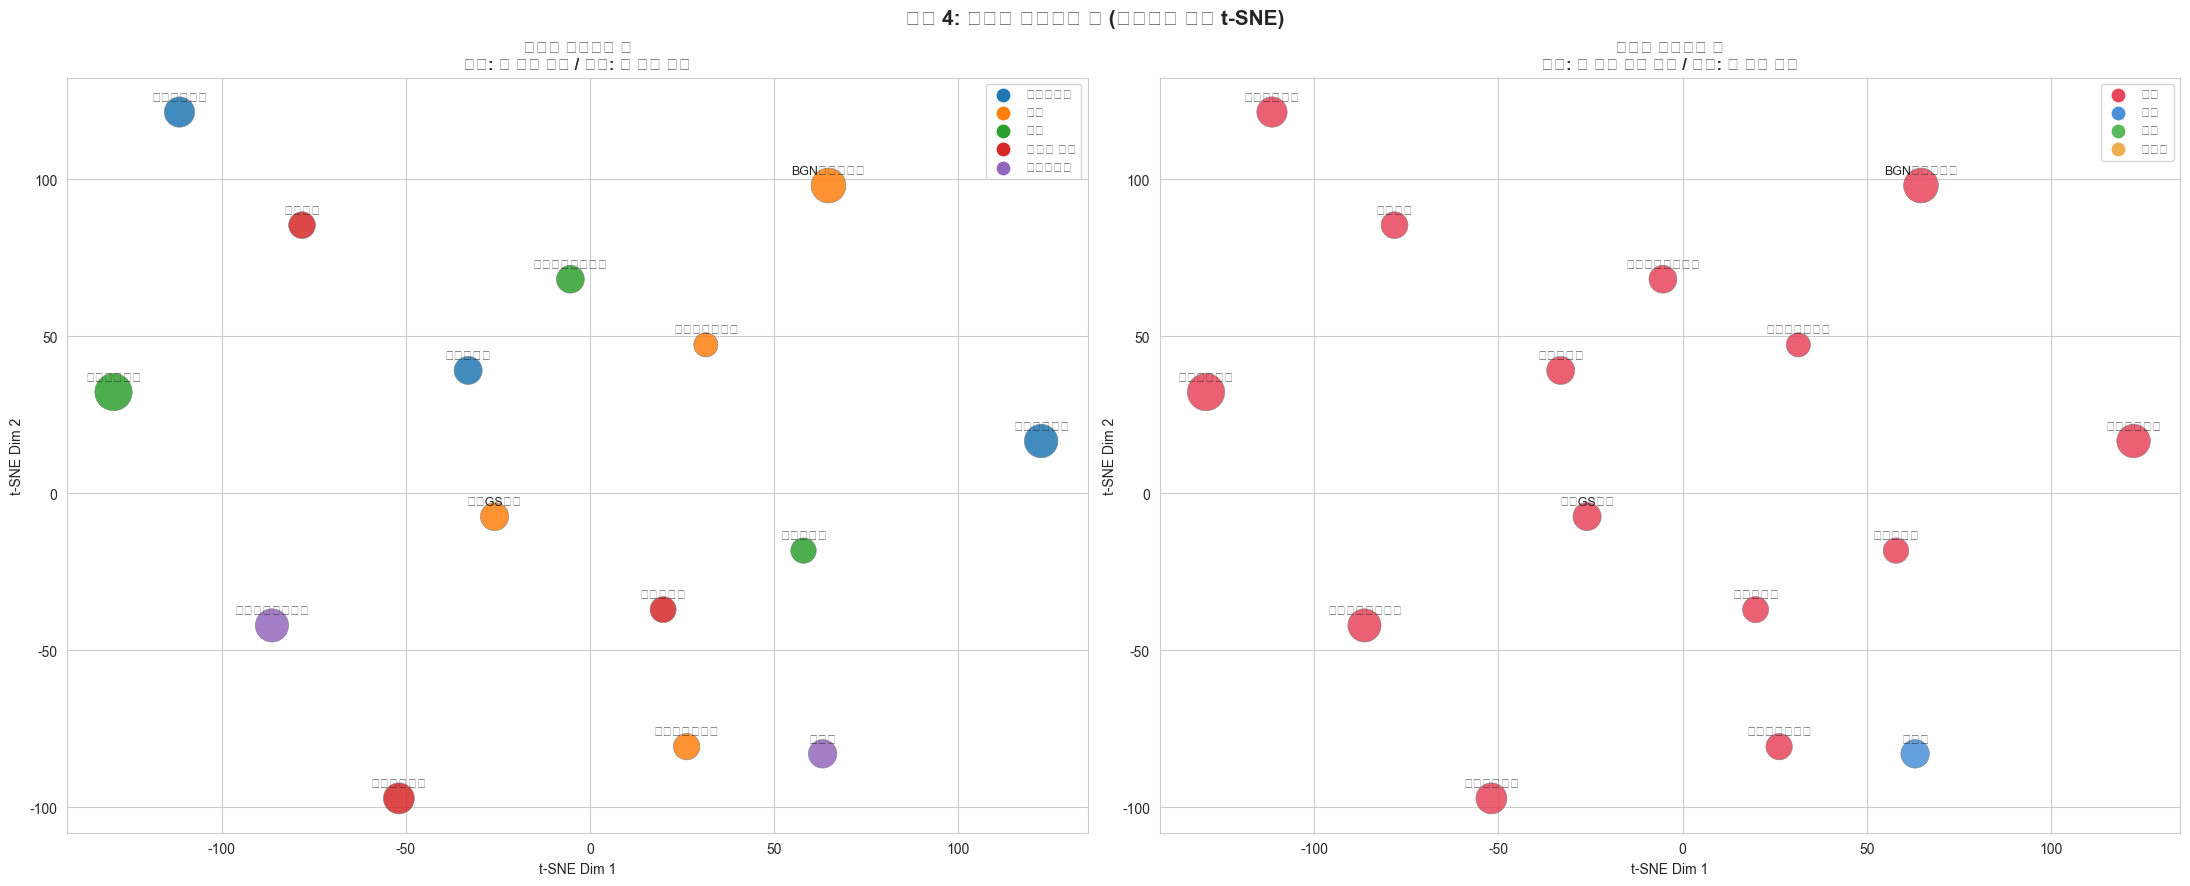

In [26]:
# 공동출현 행렬을 브랜드 feature vector로 사용 (L2 정규화)
brand_vecs = normalize(cooc, norm='l2')

n    = len(top_brands)
perp = min(max(n // 3, 2), 30)
coords = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=2000).fit_transform(brand_vecs)

PROC_COLORS = dict(zip(procedures, sns.color_palette('tab10', len(procedures))))
TYPE_COLORS = {'추천': '#E8455A', '비교': '#4A90D9', '후기': '#5CB85C', '전문가': '#F0AD4E'}

best_proc = [mat_proc.loc[b].idxmax() for b in top_brands]
best_type = [mat_type_norm.loc[b].idxmax() for b in top_brands]
sizes     = [60 + brand_counter[b] * 3 for b in top_brands]

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, best, palette, title in [
    (axes[0], best_proc, PROC_COLORS, '색상: 주 등장 시술'),
    (axes[1], best_type, TYPE_COLORS, '색상: 주 등장 질문 유형'),
]:
    colors = [palette[b] for b in best]
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=sizes,
               alpha=0.85, edgecolors='grey', lw=0.5)
    for i, brand in enumerate(top_brands):
        ax.annotate(brand, (coords[i, 0], coords[i, 1]),
                    fontsize=9, ha='center', va='bottom',
                    xytext=(0, 6), textcoords='offset points')
    for label, color in palette.items():
        ax.scatter([], [], c=[color], label=label, s=80)
    ax.legend(fontsize=9)
    ax.set_title(f'브랜드 포지셔닝 맵\n{title} / 크기: 총 언급 빈도',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')

plt.suptitle('분석 4: 브랜드 포지셔닝 맵 (공동출현 기반 t-SNE)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('analysis4_brand_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

## 분석 5 — 특정 브랜드 상세 분석
한 브랜드가 어떤 유형/시술에서 얼마나 나오는지

/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarning: Glyph 52380 (\N{HANGUL SYLLABLE CEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/11/jgtpf4p159ddl3mgf_x41fxw0000gn/T/ipykernel_41324/338563847.py:30: UserWarn

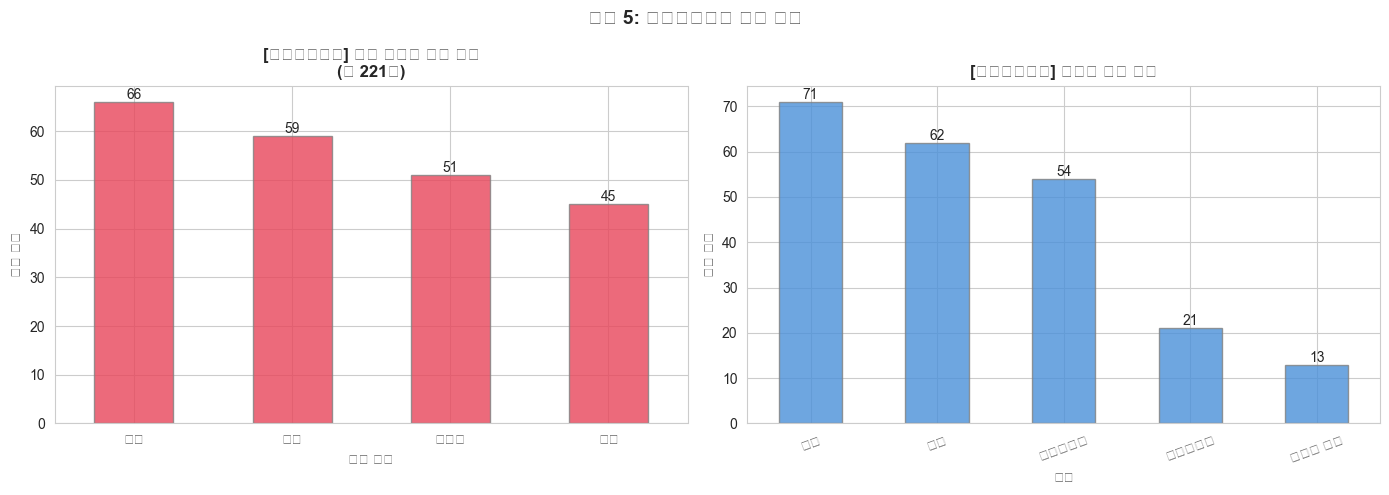


아이리움안과 전체 등장률: 22.1%
가장 자주 나오는 유형: 추천 (66회)
가장 자주 나오는 시술: 라식 (71회)


In [25]:
TARGET = top_brands[0]  # 여기 브랜드명 바꿔서 보기

rows = df[df['brand_list'].apply(lambda bl: TARGET in bl)]
total_appearances = len(rows)

type_counts = rows['유형'].value_counts()
proc_counts = rows['procedure'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts.plot(kind='bar', ax=axes[0], color='#E8455A', alpha=0.8, edgecolor='grey')
axes[0].set_title(f'[{TARGET}] 질문 유형별 등장 횟수\n(총 {total_appearances}회)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('질문 유형')
axes[0].set_ylabel('등장 횟수')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

proc_counts.plot(kind='bar', ax=axes[1], color='#4A90D9', alpha=0.8, edgecolor='grey')
axes[1].set_title(f'[{TARGET}] 시술별 등장 횟수', fontsize=12, fontweight='bold')
axes[1].set_xlabel('시술')
axes[1].set_ylabel('등장 횟수')
axes[1].tick_params(axis='x', rotation=20)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.suptitle(f'분석 5: {TARGET} 상세 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'analysis5_{TARGET}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n{TARGET} 전체 등장률: {total_appearances/len(df):.1%}')
print(f'가장 자주 나오는 유형: {type_counts.idxmax()} ({type_counts.max()}회)')
print(f'가장 자주 나오는 시술: {proc_counts.idxmax()} ({proc_counts.max()}회)')